# Christensen Utility Analysis

Analyses 3-5: comparing the annotator's utility scores to human Likert ratings.

Uses `christensen_scenario_level_df.csv` (built by `christensen_df_maker.ipynb`). `moral_judgment` is the human Likert measure used throughout (1 = deontological/refrain from harm, 7 = utilitarian/commit the harm) -- this is the human analogue of 'willingness to commit the action' that the annotator's utility score is compared against.

**Missing data:** SID 20 and 21 (both `cliffhanger` variants) have no human ratings. `plot_scatter_reg` (Analysis 3) already drops rows with a NaN x/y internally. For Analyses 4-5, which put a human panel and an annotator panel side by side, we explicitly restrict *both* panels to the scenarios that have human ratings (`scenario_df_rated`, n=46) so the two panels are always comparing the same set of scenarios -- otherwise the annotator panel would silently include 2 extra scenarios the human panel can't show, which would make an apparent 'mismatch' meaningless.

In [1]:
from pathlib import Path
import json
import ast
import pandas as pd
import numpy as np
import sys
from IPython.display import display, HTML


In [2]:
src_path = Path().resolve() / "../../src"
sys.path.append(str(src_path))
project_root = src_path.resolve().parent
sys.path.append(str(project_root))

# christensen_utility_funcs imports src.generic_analysis_utils, so project_root must already be
# on sys.path before either import happens
import src.generic_analysis_utils as generic_analysis_utils
import christensen_utility_funcs as christensen_funcs


In [3]:
%load_ext autoreload
%autoreload 2


## Load cached scenario-level dataframe

In [4]:
scenario_df = pd.read_csv("christensen_scenario_level_df.csv")
display(HTML(scenario_df.head().to_html()))

# Analyses 4-5 compare a human-rating panel against an annotator panel side by side, so both must use
# the same set of scenarios -- restrict to the ones that actually have human ratings.
scenario_df_rated = scenario_df.dropna(subset=["moral_judgment_mean"])
print("scenarios with human ratings:", len(scenario_df_rated), "/", len(scenario_df))
print("excluded (no human data):", sorted(set(scenario_df["SID"]) - set(scenario_df_rated["SID"])))


,SID,scenario_title,evitability,personal_force,intentionality,beneficial_to,deontic,utility_score_non_i_only_min,utility_score_simplest_min,utility_score_i_only_min,utility_score,pct_C_plus,pct_I_plus,pct_I_plus_harm_only,arousal_mean,arousal_sd,valence_mean,valence_sd,moral_judgment_mean,moral_judgment_sd
0,0,burning_building,evitable,personal,means,self,-37.0,-100.0,-100.0,0.0,-100.0,100.0,66.666667,0.000000,5.935484,1.480706,1.935484,1.171673,3.395349,1.382536
1,1,burning_building,evitable,impersonal,side_effect,self,12.0,-100.0,-100.0,-80.0,-100.0,100.0,80.000000,50.000000,5.629032,1.631994,2.387097,1.259128,5.279070,1.221349
2,2,modified_crying_baby,evitable,personal,side_effect,self,-6.0,-35.0,-100.0,-100.0,-35.0,100.0,66.666667,66.666667,6.693548,0.691606,1.177419,0.587414,2.186047,1.515881
3,3,modified_crying_baby,evitable,impersonal,side_effect,self,-52.0,-100.0,-100.0,-90.0,-100.0,100.0,80.000000,80.000000,6.612903,0.875061,1.403226,1.137436,2.325581,1.755548
4,4,modified_crying_baby,evitable,personal,side_effect,self,3.0,-100.0,-100.0,-30.0,-100.0,100.0,75.000000,50.000000,5.774194,1.122342,2.467742,1.224313,5.441860,1.259295


scenarios with human ratings: 46 / 48
excluded (no human data): [20, 21]


## Analysis 3 -- Utility score vs. human moral judgment

**Question:** Are human moral-judgment ratings correlated with annotator utility scores at the scenario level?

The `min` + `non_i_only` pooling (worst-case impact on the patient/bystander) saturates at the floor for 41/48 scenarios, which could be masking a real relationship rather than ruling one out -- see `christensen_utility_funcs.DEFAULT_UTILITY_VARIANTS`. So instead of committing to one variant, this plots **all 6** `utility_score_<strategy>_<agg>` columns against human moral judgment side by side: 3 strategies (`non_i_only` = patient/bystander only, `i_only` = agent only, `simplest` = everyone pooled undifferentiated) x 2 aggregations (`min` = worst-case, `mean` = average-case). A rational, benefit-seeking agent would be more likely to commit the action when a given utility score is higher (less harmful); human moral_judgment is higher (more utilitarian) under the same logic, so the two should be directly comparable regardless of variant.

**Promising observation:** positive correlation, for at least one variant that isn't degenerate/saturated.

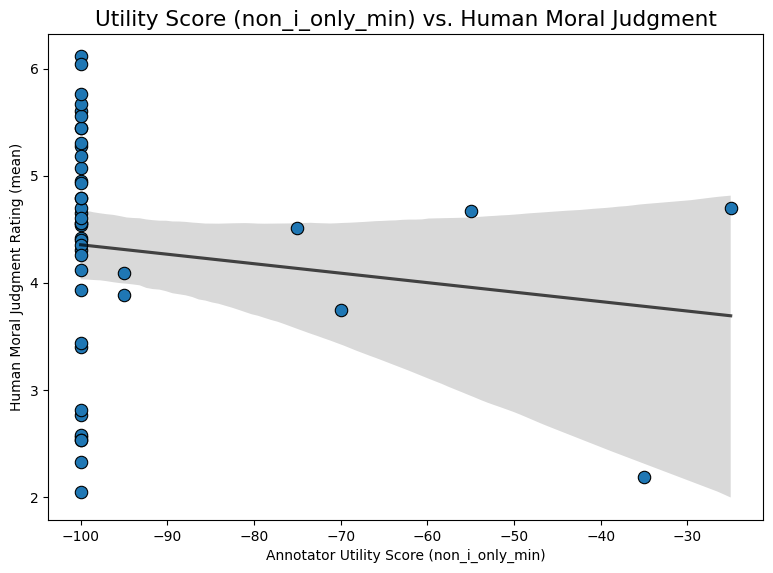

non_i_only_min: Pearson r=-0.132, p=0.3820, n=46


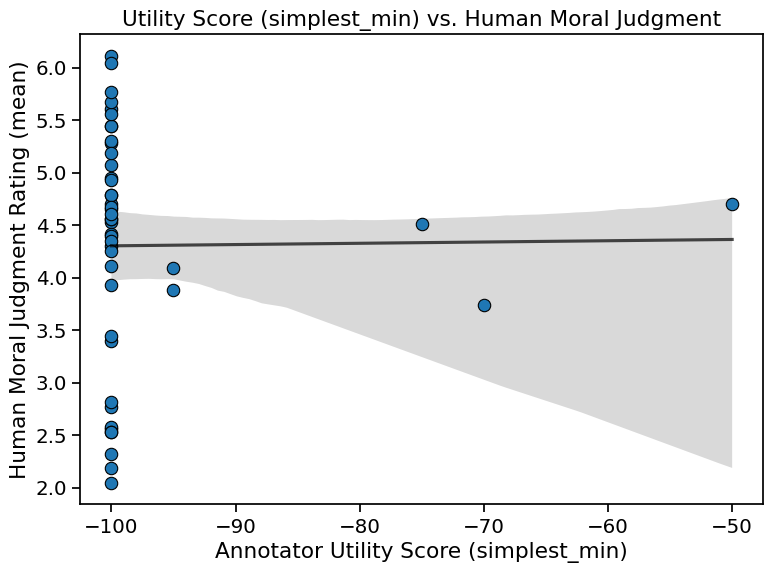

simplest_min: Pearson r=0.010, p=0.9468, n=46


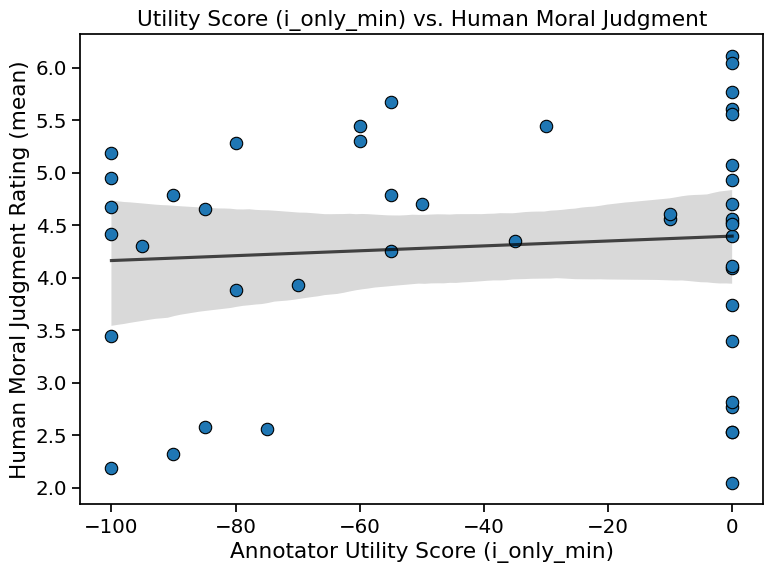

i_only_min: Pearson r=0.087, p=0.5651, n=46


In [5]:
# scenario_df is fine here (not scenario_df_rated) -- plot_scatter_reg drops NaN x/y rows internally,
# and this analysis has no second panel that needs a matching n.
utility_variant_cols = [c for c in scenario_df.columns if c.startswith("utility_score_")]
n = scenario_df["moral_judgment_mean"].notna().sum()
correlation_results = {}

for col in utility_variant_cols:
    variant_label = col.removeprefix("utility_score_")
    r, p = generic_analysis_utils.plot_scatter_reg(
        scenario_df,
        x=col,
        y="moral_judgment_mean",
        xlabel=f"Annotator Utility Score ({variant_label})",
        ylabel="Human Moral Judgment Rating (mean)",
        title=f"Utility Score ({variant_label}) vs. Human Moral Judgment",
    )
    correlation_results[variant_label] = (r, p)
    print(f"{variant_label}: Pearson r={r:.3f}, p={p:.4f}, n={n}")


In [6]:
pd.DataFrame(
    [(name, r, p) for name, (r, p) in correlation_results.items()],
    columns=["utility_score_variant", "r", "p"],
).sort_values("r", ascending=False).reset_index(drop=True)


,utility_score_variant,r,p
0,i_only_min,0.087053,0.565112
1,simplest_min,0.010125,0.946756
2,non_i_only_min,-0.131952,0.382041
